In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [8]:
load_dotenv()

True

In [5]:
llm = ChatOpenAI()

In [ ]:
search_tool = TavilySearch(max_results=5, topic="general", search_depth="advanced")

In [ ]:
@tool
def calculator(expression: str) -> str:
    """Use this to calculate the result of a math expression."""
    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "ceil": math.ceil,
            "floor": math.floor,
            "sqrt": math.sqrt,
            "sin": math.sin,
            "cos": math.cos,
            "min": min,
            "max": max,
            "sum": sum,
            "prod": math.prod,
            "factorial": math.factorial,
            "log": math.log,
            "exp": math.exp,
            "pow": math.pow,
            "sqrt": math.sqrt,
        }
        result = eval(expression,{"__builtins__": {}}, allowed)
        return f"The result of {expression} is {result}"
    except Exception as e:
        return f"Calculator Error: {e}"
    

@tool
def get_stock_price(ticker: str) -> str:
    """Use this to get the current stock price of a company."""
    try:
        response = requests.get(f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={ticker}&apikey=HTM6MLWOXVJCK77J")
        response.raise_for_status()
        data = response.json()
        return data
    except Exception as e:
        return f"Stock Price Error: {e}"

    

In [ ]:
tools = [search_tool, calculator, get_stock_price]
llm_with_tools = llm.bind_tools(tools)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [18]:
def chat_node(state: ChatState) -> ChatState:
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    messages.append(response)
    return {"messages": messages}

tool_node = ToolNode(tools)

In [21]:
graph = StateGraph(ChatState)
graph.add_node("tools", tool_node)
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")



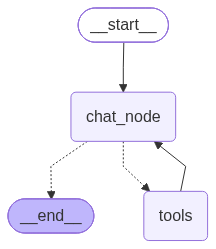

In [22]:
chatbot = graph.compile()
chatbot

In [23]:
out = chatbot.invoke({"messages": [HumanMessage(content="Hello?")]})
print(out["messages"][-1].content)

Hello! How can I assist you today?


In [24]:
out = chatbot.invoke({"messages": [HumanMessage(content="What is 8989*9090+5040")]})
print(out["messages"][-1].content)

The result of the expression 8989*9090+5040 is 81715050.


In [26]:
out = chatbot.invoke({"messages": [HumanMessage(content="what is the new movie releases in October 2026")]})
print(out["messages"][-1].content[0])

I
